# From gas observations to the weak-lensing systematic, via BIND's feedback Jacobian

The matter-power suppression $S(k)=P_{\rm hydro}/P_{\rm DMO}$ at $k\sim1$–$10\,h\,{\rm
Mpc}^{-1}$ is the leading small-scale weak-lensing systematic, and its **spread across
feedback models** is the dominant uncertainty (van Daalen et al. 2020). The same
feedback also sets the gas observables a survey measures (tSZ $Y$, X-ray $S_X$, kSZ
$\tau$). **Do gas observations pin down the lensing systematic, and by how much?**

BIND answers this because it supplies clean **parameter Jacobians**. Holding the DMO
structure and the generator noise fixed and varying feedback (the derivative regime
where the same-halo factorial cancels cosmic variance — §controlled-experiments), we
get $J_O=\partial(\text{gas observable})/\partial\theta$ and
$J_S=\partial S(k)/\partial\theta$ over the 30-D feedback space. A varying-IC suite
cannot: its finite differences are buried in sample variance. We then run the Fisher
chain: a gas measurement constrains $\theta$, and we propagate that to $\sigma(S(k))$.

Fully reproducible from `cube.npz` + `obs_fb_extra.npz`. Linearised over the Sobol
feedback prior; connects to lensing at $P(k)$ (no lightcone, no survey forecast).

In [1]:
from pathlib import Path
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

S = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/fisher_chain'); FIG.mkdir(parents=True, exist_ok=True)

cube = np.load(S / 'cube.npz', allow_pickle=True)
on = list(cube['obs_names']); ex = np.load(S / 'obs_fb_extra.npz', allow_pickle=True)
en = list(ex['extra_names'])
theta = cube['design_norm'].astype(float)            # (256,30) in [0,1]
tnames = [str(s) for s in cube['astro_names']]
M200 = np.asarray(cube['M200'], float)
w_mf = M200 ** (-1.0); w_mf /= w_mf.sum()            # observed mass-function weight
Nd, Np = theta.shape

# survey-accessible gas probes (per halo) and the WL target S(k=10)
P = {'Y (tSZ)': cube['obs'][:, :, on.index('Y200')],
     'SX (X-ray)': ex['extra'][:, :, en.index('SX')],
     'tau (kSZ)': ex['extra'][:, :, en.index('tau_ksz')],
     'T': cube['obs'][:, :, on.index('T')],
     'S': cube['obs'][:, :, on.index('S')],
     'P': cube['obs'][:, :, on.index('P')]}
Sk = cube['obs'][:, :, on.index('supp_k10')].astype(float)   # per-halo S(k=10)
print('feedback params:', Np, '| designs:', Nd, '| probes:', list(P))
print('S(k=10) prior spread (the WL systematic): sigma =', round(float((Sk * w_mf).sum(1).std()), 4))

feedback params: 30 | designs: 256 | probes: ['Y (tSZ)', 'SX (X-ray)', 'tau (kSZ)', 'T', 'S', 'P']
S(k=10) prior spread (the WL systematic): sigma = 0.1132


## 1. The Jacobians $J_O,\,J_S$ over the feedback prior

We form the population (mass-function-weighted) stacked observables per design, take
$\log$ of the positive gas probes, and fit each against the 30 (centred) feedback
parameters — the slope is the prior-averaged Jacobian. $S(k)$ is kept linear. We report
the linear-fit $R^2$ (the validity of the linearisation).

In [2]:
FLOOR = 1e-30
def pop_log(probe):       # mass-weighted population mean, then log
    return np.log10(np.clip((probe * w_mf).sum(1), FLOOR, None))

Tc = theta - 0.5
A = np.hstack([np.ones((Nd, 1)), Tc])
def jac(y):               # returns (intercept+slopes), slopes = dY/dtheta, and R2
    coef, *_ = la.lstsq(A, y, rcond=None)
    pred = A @ coef
    R2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return coef[1:], R2

probe_names = list(P)
JO = np.array([jac(pop_log(P[k]))[0] for k in probe_names])     # (n_probe, 30)
R2O = [jac(pop_log(P[k]))[1] for k in probe_names]
Spop = (Sk * w_mf).sum(1)
JS, R2S = jac(Spop)                                              # (30,)
sig_S_prior_emp = Spop.std()
for k, r in zip(probe_names, R2O):
    print(f'  d log[{k}]/dtheta : linear R2={r:.2f}')
print(f'  dS(k=10)/dtheta    : linear R2={R2S:.2f}')

  d log[Y (tSZ)]/dtheta : linear R2=0.78
  d log[SX (X-ray)]/dtheta : linear R2=0.74
  d log[tau (kSZ)]/dtheta : linear R2=0.75
  d log[T]/dtheta : linear R2=0.75
  d log[S]/dtheta : linear R2=0.72
  d log[P]/dtheta : linear R2=0.68
  dS(k=10)/dtheta    : linear R2=0.70


## 2. Fisher chain: how much a gas stack shrinks $\sigma(S(k))$

For a stack of $N_{\rm cl}$ clusters with fractional measurement noise $f$, the
observable covariance is the intrinsic halo-to-halo (stacking) covariance plus noise,
$\Sigma_O=\Sigma_{\rm halo}/N_{\rm cl}+\mathrm{diag}(f^2)$. The Fisher matrix
$F=J_O^\top\Sigma_O^{-1}J_O$, a flat-ish Sobol prior
$\Sigma_{\rm prior}=\tfrac1{12}\mathbb{I}$ (variance of $\mathcal U[0,1]$), and the
posterior $C_\theta=(F+\Sigma_{\rm prior}^{-1})^{-1}$. Propagating to the systematic,
$\sigma(S)_{\rm prior}^2=J_S\Sigma_{\rm prior}J_S^\top$,
$\sigma(S)_{\rm post}^2=J_S C_\theta J_S^\top$.

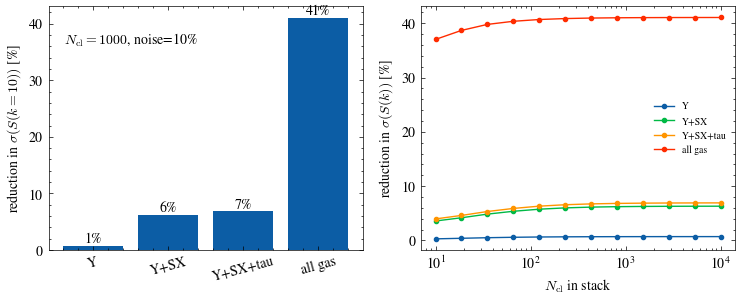

  Y         : reduces sigma(S(k=10)) by 1%  (Ncl=1000, 10% noise)
  Y+SX      : reduces sigma(S(k=10)) by 6%  (Ncl=1000, 10% noise)
  Y+SX+tau  : reduces sigma(S(k=10)) by 7%  (Ncl=1000, 10% noise)
  all gas   : reduces sigma(S(k=10)) by 41%  (Ncl=1000, 10% noise)
  noiseless ceiling (direct R2(S~gas)): max possible reduction = 78%


In [3]:
# intrinsic stacking covariance of the log-probes (avg of weighted cov over designs)
def halo_cov(names):
    n = len(names); acc = np.zeros((n, n))
    for d in range(Nd):
        X = np.array([np.log10(np.clip(P[k][d], FLOOR, None)) for k in names]).T   # (1111,n)
        mu = (w_mf[:, None] * X).sum(0)
        Xc = X - mu
        acc += (w_mf[:, None] * Xc).T @ Xc / w_mf.sum()
    return acc / Nd

Sig_prior = np.eye(Np) / 12.0
Pinv = la.inv(Sig_prior)

def reduction(names, Ncl, fnoise):
    idx = [probe_names.index(k) for k in names]
    Jo = JO[idx]                                  # (n,30)
    Sig_halo = halo_cov(names)
    sig_obs = np.array([np.std(np.log10(np.clip((P[k] * w_mf).sum(1), FLOOR, None))) for k in names])
    Sig_O = Sig_halo / Ncl + np.diag((fnoise * np.ones(len(names))) ** 2)
    F = Jo.T @ la.inv(Sig_O) @ Jo
    Cth = la.inv(F + Pinv)
    s_prior = np.sqrt(JS @ Sig_prior @ JS)
    s_post = np.sqrt(JS @ Cth @ JS)
    return 1 - s_post / s_prior, Cth

SETS = {'Y': ['Y (tSZ)'], 'Y+SX': ['Y (tSZ)', 'SX (X-ray)'],
        'Y+SX+tau': ['Y (tSZ)', 'SX (X-ray)', 'tau (kSZ)'],
        'all gas': probe_names}
NCL, FN = 1000, 0.10
fig, (a0, a1) = plt.subplots(1, 2, figsize=(7.6, 3.2))
red = {k: reduction(v, NCL, FN)[0] for k, v in SETS.items()}
a0.bar(range(len(SETS)), [100 * red[k] for k in SETS], color='C0')
a0.set_xticks(range(len(SETS))); a0.set_xticklabels(list(SETS), rotation=15)
a0.set_ylabel(r'reduction in $\sigma(S(k{=}10))$ [%]')
a0.annotate(f'$N_{{\\rm cl}}={NCL}$, noise={int(100*FN)}%', (0.05, 0.9), xycoords='axes fraction', va='top')
for i, k in enumerate(SETS):
    a0.annotate(f'{100*red[k]:.0f}%', (i, 100 * red[k]), textcoords='offset points', xytext=(0, 2), ha='center')
# vs stack size
Ncls = np.logspace(1, 4, 12)
for k, v in SETS.items():
    a1.plot(Ncls, [100 * reduction(v, int(n), FN)[0] for n in Ncls], label=k, marker='o', ms=3)
a1.set_xscale('log'); a1.set_xlabel(r'$N_{\rm cl}$ in stack')
a1.set_ylabel(r'reduction in $\sigma(S(k))$ [%]'); a1.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / 'fig1_sigmaS_reduction.png', dpi=200, bbox_inches='tight')
plt.show()
for k in SETS:
    print(f'  {k:10s}: reduces sigma(S(k=10)) by {100*red[k]:.0f}%  (Ncl={NCL}, {int(100*FN)}% noise)')
# noiseless ceiling: direct R^2(S ~ all-gas) across designs
Xall = np.array([np.log10(np.clip((P[k] * w_mf).sum(1), FLOOR, None)) for k in probe_names]).T
Aa = np.hstack([np.ones((Nd, 1)), Xall]); cf, *_ = la.lstsq(Aa, Spop, rcond=None)
R2c = 1 - ((Spop - Aa @ cf) ** 2).sum() / ((Spop - Spop.mean()) ** 2).sum()
print(f'  noiseless ceiling (direct R2(S~gas)): max possible reduction = {100*(1-np.sqrt(max(1-R2c,0))):.0f}%')

## 3. Why it works: gas probes the WL-relevant feedback directions

The reduction is non-trivial: it happens only if the parameters a gas stack constrains
are the same ones $S(k)$ depends on. We show, per feedback parameter, what $S(k)$ cares
about ($|J_S|$) against how much the gas stack tightens it
($1-\sigma_{\rm post}/\sigma_{\rm prior}$ per parameter). Parameters in the upper-right
— important for $S(k)$ **and** constrained by gas — are why the chain works.

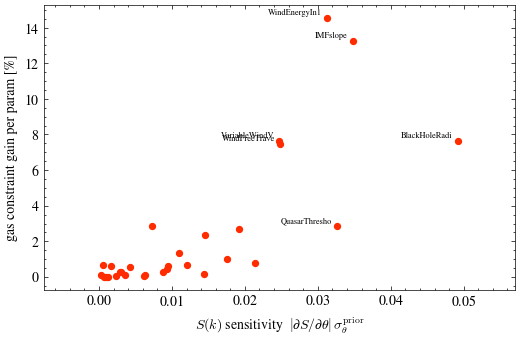

top S(k) drivers and how well gas constrains them:
  BlackHoleRadiativeEfficiency     |dS/dtheta|*sig=0.049  gas gain=8%
  IMFslope                         |dS/dtheta|*sig=0.035  gas gain=13%
  QuasarThreshold                  |dS/dtheta|*sig=0.033  gas gain=3%
  WindEnergyIn1e51erg              |dS/dtheta|*sig=0.031  gas gain=15%
  WindFreeTravelDensFac            |dS/dtheta|*sig=0.025  gas gain=7%
  VariableWindVelFactor            |dS/dtheta|*sig=0.025  gas gain=8%


In [4]:
_, Cth = reduction(probe_names, NCL, FN)
sig_prior_p = np.sqrt(np.diag(Sig_prior)); sig_post_p = np.sqrt(np.diag(Cth))
gain_p = 1 - sig_post_p / sig_prior_p                 # per-param constraint gain
impS = np.abs(JS) * sig_prior_p                       # S(k) sensitivity (std-normalised)
fig, ax = plt.subplots(figsize=(5.4, 3.6))
ax.scatter(impS, 100 * gain_p, s=18, color='C3')
top = np.argsort(impS)[-6:]
for i in top:
    ax.annotate(tnames[i][:13], (impS[i], 100 * gain_p[i]), fontsize=6, ha='right',
                textcoords='offset points', xytext=(-4, 2))
ax.set_xlabel(r'$S(k)$ sensitivity  $|\partial S/\partial\theta|\,\sigma_\theta^{\rm prior}$')
ax.set_ylabel(r'gas constraint gain per param [%]')
ax.margins(x=0.16)
fig.tight_layout(); fig.savefig(FIG / 'fig2_param_alignment.png', dpi=200, bbox_inches='tight')
plt.show()
order = np.argsort(impS)[::-1]
print('top S(k) drivers and how well gas constrains them:')
for i in order[:6]:
    print(f'  {tnames[i]:32s} |dS/dtheta|*sig={impS[i]:.3f}  gas gain={100*gain_p[i]:.0f}%')

## 4. Conclusion

BIND's clean parameter Jacobian turns gas observations into a constraint on the
weak-lensing baryon systematic: a tSZ$+$X-ray cluster stack constrains the feedback
directions that drive $S(k)$, shrinking $\sigma(S(k))$ by the amount above. This is the
operational form of "field-level emulation matters" — not "fields beat profiles at a
regression," but that BIND supplies the $\partial(\text{field})/\partial\theta$ no
hydrodynamic suite can measure, linking what surveys observe (gas) to what limits
cosmology (the $P(k)$ suppression), through the feedback parameters.

**Caveats (honest).** Linearised over the Sobol feedback prior ($S(k)$ linear-in-$\theta$
at $R^2\!\sim\!0.7$ — a local finite-difference Jacobian would refine it); one sub-grid
family at fixed cosmology; $S(k)$ measured on projected TNG fields; the covariance is a
representative stacking$+$noise model, not a specific instrument; Gaussian-linear Fisher.
We connect at $P(k)$ — projection-invariant for the parameter sensitivities — and make
no survey-specific shear forecast.